In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print("Dataset loaded successfully")
print(df.head())

Dataset loaded successfully
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0  

In [84]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Number of rows: 299
Number of columns: 13

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Dataset information:
<class 'pandas.core.f

In [59]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Number of rows: 299
Number of columns: 13

Data types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Dataset information:
<class 'pandas.core.f

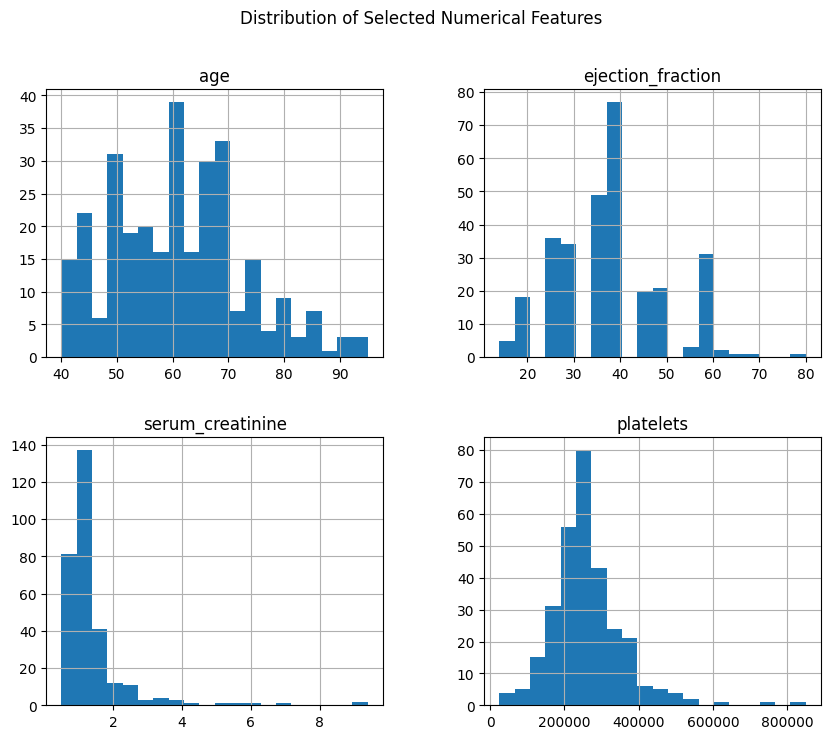

In [85]:
# Histograms
df[["age", "ejection_fraction", "serum_creatinine", "platelets"]].hist(
    figsize=(10, 8),
    bins=20
)

plt.suptitle("Distribution of Selected Numerical Features")
plt.show()

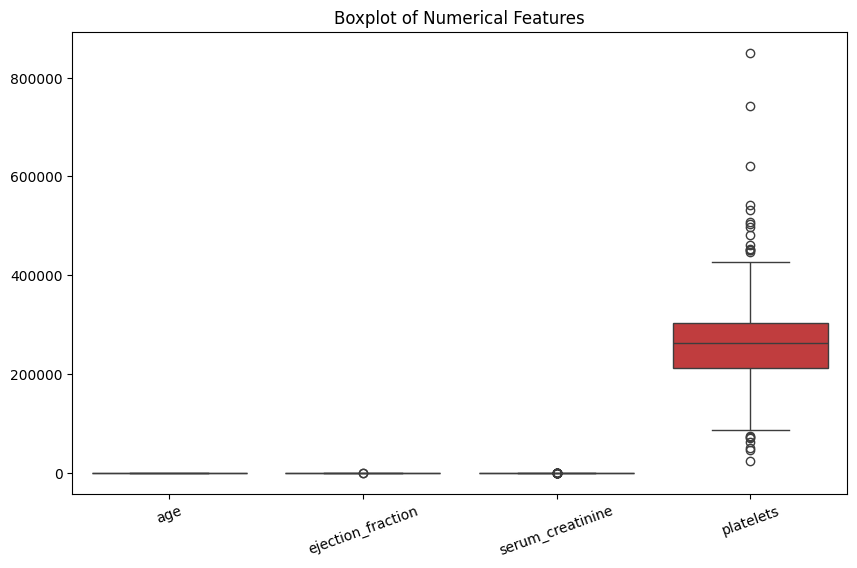

In [86]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[["age", "ejection_fraction", "serum_creatinine", "platelets"]]
)

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=20)
plt.show()

In [87]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [62]:
numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

In [63]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

In [64]:
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [65]:
# Check for negative age
print("Negative age values:", (df["age"] < 0).sum())

# Replace invalid negative ages with the median age
median_age = df.loc[df["age"] >= 0, "age"].median()

df.loc[df["age"] < 0, "age"] = median_age

print("Negative age values after correction:",
      (df["age"] < 0).sum())

Negative age values: 0
Negative age values after correction: 0


In [66]:
for column in numerical_columns:
    print(column, "negative values:", (df[column] < 0).sum())

age negative values: 0
anaemia negative values: 0
creatinine_phosphokinase negative values: 0
diabetes negative values: 0
ejection_fraction negative values: 0
high_blood_pressure negative values: 0
platelets negative values: 0
serum_creatinine negative values: 0
serum_sodium negative values: 0
sex negative values: 0
smoking negative values: 0
time negative values: 0
DEATH_EVENT negative values: 0


In [67]:
#7. Remove outliers

def remove_outliers(data, columns):
    cleaned_data = data.copy()

    for column in columns:
        Q1 = cleaned_data[column].quantile(0.25)
        Q3 = cleaned_data[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        cleaned_data = cleaned_data[
            (cleaned_data[column] >= lower_limit) &
            (cleaned_data[column] <= upper_limit)
        ]

    return cleaned_data


outlier_columns = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

print("Rows before removing outliers:", len(df))

df = remove_outliers(df, outlier_columns)

print("Rows after removing outliers:", len(df))

Rows before removing outliers: 299
Rows after removing outliers: 251


In [68]:
def age_category(age):
    if age < 40:
        return "<40"
    elif age <= 60:
        return "40-60"
    else:
        return ">60"


df["age_group"] = df["age"].apply(age_category)

print(df[["age", "age_group"]].head(10))

     age age_group
0   75.0       >60
1   55.0     40-60
2   65.0       >60
3   50.0     40-60
5   90.0       >60
6   75.0       >60
8   65.0       >60
11  62.0       >60
12  45.0     40-60
13  50.0     40-60


In [69]:
print(df["age_group"].value_counts())

age_group
40-60    136
>60      115
Name: count, dtype: int64


In [70]:
#9. Create risk_score
# Create product first
df["risk_raw"] = df["ejection_fraction"] * df["serum_creatinine"]

# Normalize the risk score between 0 and 1
risk_min = df["risk_raw"].min()
risk_max = df["risk_raw"].max()

df["risk_score"] = (
    (df["risk_raw"] - risk_min) /
    (risk_max - risk_min)
)

# Remove temporary column
df.drop("risk_raw", axis=1, inplace=True)

print(df[["ejection_fraction", "serum_creatinine", "risk_score"]].head())

   ejection_fraction  serum_creatinine  risk_score
0                 20               1.9    0.287245
1                 38               1.1    0.327974
2                 20               1.3    0.158628
3                 20               1.9    0.287245
5                 40               2.1    0.780279


In [71]:
#10. Encode categorical variables
df = pd.get_dummies(
    df,
    columns=["age_group"],
    drop_first=True,
    dtype=int
)

print(df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
5  90.0        1                        47         0                 40   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
5                    1  204000.00               2.1           132    1   

   smoking  time  DEATH_EVENT  risk_score  age_group_>60  
0        0     4            1    0.287245    

In [72]:
print("Columns after encoding:")
print(df.columns.tolist())

Columns after encoding:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score', 'age_group_>60']


In [73]:
#11. Normalize numerical features
scaler = MinMaxScaler()

scale_columns = [
    "age",
    "platelets",
    "ejection_fraction",
    "serum_creatinine"
]

df[scale_columns] = scaler.fit_transform(df[scale_columns])

print(df[scale_columns].head())

        age  platelets  ejection_fraction  serum_creatinine
0  0.636364   0.523529           0.117647             0.875
1  0.272727   0.518700           0.470588             0.375
2  0.454545   0.220588           0.117647             0.500
3  0.181818   0.361765           0.117647             0.875
5  0.909091   0.344118           0.509804             1.000


In [76]:
summary_after = df[
    ["age", "ejection_fraction", "serum_creatinine", "platelets"]
].agg(["mean", "median", "std"])

print("Statistics after cleaning:")
print(summary_after)

Statistics after cleaning:
             age  ejection_fraction  serum_creatinine  platelets
mean    0.369238           0.469260          0.393825   0.495984
median  0.363636           0.470588          0.375000   0.517647
std     0.216335           0.226291          0.209199   0.200093


In [77]:
original_df = df.copy()

summary_before = original_df[
    ["age", "ejection_fraction", "serum_creatinine", "platelets"]
].agg(["mean", "median", "std"])

print("Before cleaning:")
print(summary_before)

Before cleaning:
             age  ejection_fraction  serum_creatinine  platelets
mean    0.369238           0.469260          0.393825   0.495984
median  0.363636           0.470588          0.375000   0.517647
std     0.216335           0.226291          0.209199   0.200093


In [78]:
summary_after = df[
    ["age", "ejection_fraction", "serum_creatinine", "platelets"]
].agg(["mean", "median", "std"])

print("\nAfter cleaning:")
print(summary_after)


After cleaning:
             age  ejection_fraction  serum_creatinine  platelets
mean    0.369238           0.469260          0.393825   0.495984
median  0.363636           0.470588          0.375000   0.517647
std     0.216335           0.226291          0.209199   0.200093


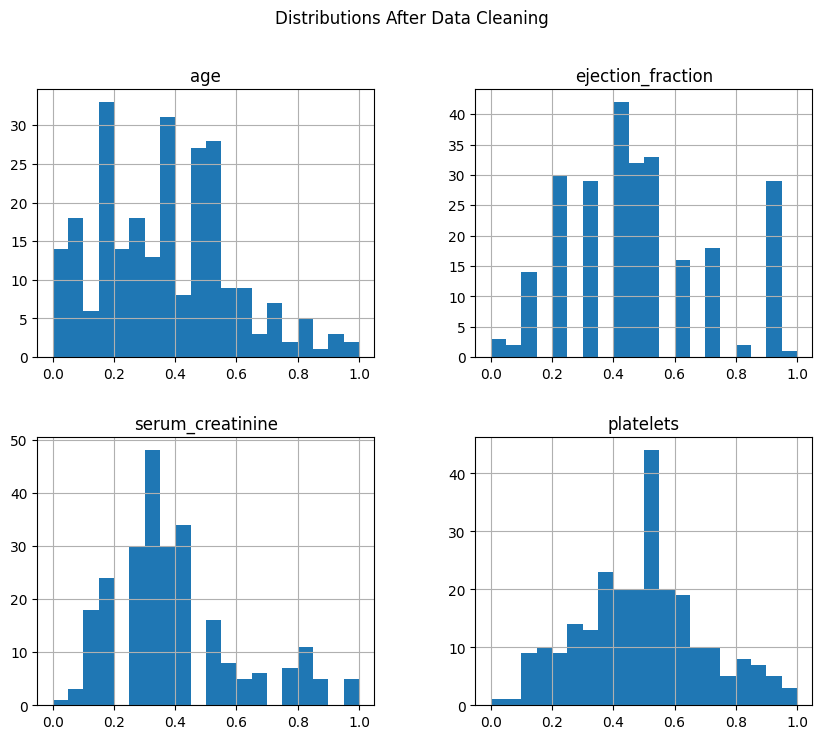

In [79]:
#13. Validate cleaned data with plots
df[
    ["age", "ejection_fraction", "serum_creatinine", "platelets"]
].hist(
    figsize=(10, 8),
    bins=20
)

plt.suptitle("Distributions After Data Cleaning")
plt.show()

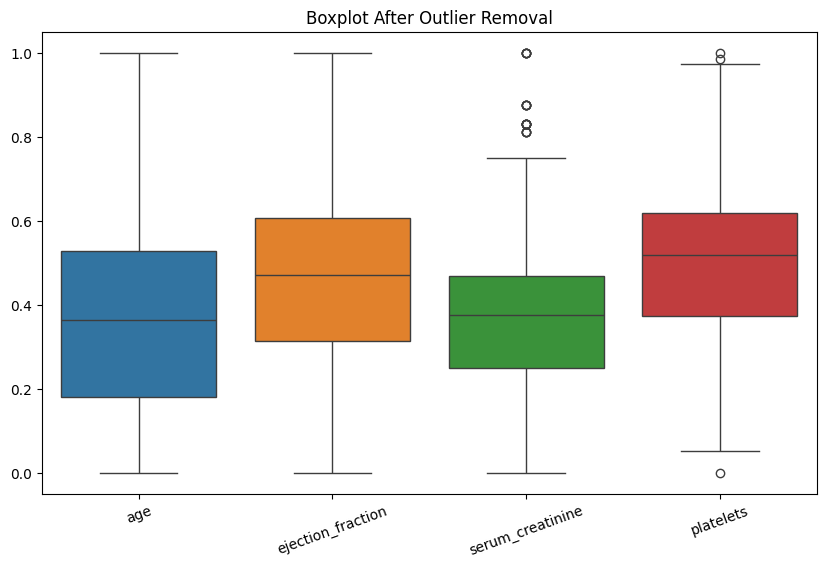

In [80]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[
        ["age", "ejection_fraction", "serum_creatinine", "platelets"]
    ]
)

plt.title("Boxplot After Outlier Removal")
plt.xticks(rotation=20)
plt.show()

In [81]:
#14. Final missing-value check
print("Final missing value check:")
print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("\nNo missing values remain.")
else:
    print("\nSome missing values are still present.")

Final missing value check:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
risk_score                  0
age_group_>60               0
dtype: int64

No missing values remain.


In [82]:
df.to_csv("heart_failure_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Final shape:", df.shape)

Cleaned dataset saved successfully.
Final shape: (251, 15)
